## 1. Boilerplate

In [1]:
import sys, logging, pickle
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import spearmanr

from src.evaluation.backtester import NestedLOYOBacktester, BacktestResult
from src.evaluation.metrics import (
    compute_all_metrics, compute_round_breakdown,
    compute_expert_agreement, compute_logloss,
)
from src.evaluation.calibration import (
    compute_calibration_curve, compute_calibration_error,
    compute_per_expert_calibration,
)
from src.data.merge import merge_kenpom_with_matchups
from src.config import EXPERT_TYPES, FIRST_YEAR, LAST_YEAR, SKIP_YEARS, ESPN_ROUND_POINTS

sns.set_theme(style="whitegrid")
logging.basicConfig(level=logging.INFO)
pd.set_option("display.max_columns", 50)

## 2. Run Full Nested LOYO

In [2]:
cache_path = Path("../data/cache/backtest_moe.pkl")
cache_path.parent.mkdir(parents=True, exist_ok=True)

if cache_path.exists():
    with open(cache_path, "rb") as f:
        moe_result = pickle.load(f)
    print("Loaded cached MOE backtest result")
else:
    merged_df = merge_kenpom_with_matchups()
    backtester = NestedLOYOBacktester()
    moe_result = backtester.run(merged_df)
    with open(cache_path, "wb") as f:
        pickle.dump(moe_result, f)
print(moe_result.summary()) 

INFO:src.data.kaggle_loader:Loading DEV table from /Users/austinsalter/Documents/Projects/March-Madness-MOE/data/raw/kenpom/DEV _ March Madness.csv
INFO:src.data.kaggle_loader:Loaded DEV table: 8315 rows, 24 seasons (2002–2025), 38 columns
INFO:src.data.kaggle_loader:Loading pomeroy ratings from /Users/austinsalter/Documents/Projects/March-Madness-MOE/data/cache/kenpom_pomeroy_ratings.parquet
INFO:src.data.kaggle_loader:Loaded pomeroy ratings: 8679 rows, 25 seasons
INFO:src.data.kaggle_loader:Pomeroy merge: 7607/8315 matched. 708 unmatched (mostly non-tournament): ['Miami', 'Pennsylvania', 'Little Rock', 'McNeese', 'IU Indianapolis', 'Sam Houston', 'Missouri State', 'Louisiana', 'Miami (OH)', 'Charleston']
INFO:src.data.kaggle_loader:Final KenPom dataset: 8314 rows, 43 columns, seasons 2002–2025
INFO:src.data.tournament_data:Dropping 63 First Four / play-in games
INFO:src.data.tournament_data:Loaded 1386 tournament matchups across 22 seasons (2003–2025)
INFO:src.data.merge:Merge comple

=== Backtest Summary ===
  logloss: 0.4458
  accuracy: 0.8249
  brier_score: 0.1410
  espn_bracket_score: 33280.0000

  Total predictions: 1388
  Years tested: 22

  Expert agreement (Spearman):
                         seed_baseline  efficiency_delta  uncertainty_calibration
seed_baseline                 1.000000          0.837871                 0.409416
efficiency_delta              0.837871          1.000000                 0.458461
uncertainty_calibration       0.409416          0.458461                 1.000000

  Blend ECE: 0.0935


## 3. Run Baseline

In [3]:
cache_bl = Path("../data/cache/backtest_baseline.pkl")
if cache_bl.exists():
    with open(cache_bl, "rb") as f:
        bl_result = pickle.load(f)
    print("Loaded cached baseline backtest result")
else:
    if "merged_df" not in dir():
        merged_df = merge_kenpom_with_matchups()
    backtester_bl = NestedLOYOBacktester()
    bl_result = backtester_bl.run_baseline(merged_df)
    with open(cache_bl, "wb") as f:
        pickle.dump(bl_result, f)
print(bl_result.summary())

INFO:src.evaluation.backtester:Baseline fold: test_year=2003
INFO:src.features.pipeline:Building features for split: 1325 train games (21 seasons), 63 test games (1 seasons)
INFO:src.features.kenpom_deltas:Detected 34 stat pairs for deltas: ['adjde', 'adjem', 'adjoe', 'adjtempo', 'avg_height', 'bench', 'def_arate', 'def_blockpct', 'def_fg2pct', 'def_fg3pct', 'def_fg3rate', 'def_ftpct', 'def_nstrate', 'def_stlrate', 'eff_height', 'experience', 'luck', 'ncsos_adjem', 'net_rating', 'off_arate', 'off_blockpct', 'off_efgpct', 'off_fg2pct', 'off_fg3pct', 'off_fg3rate', 'off_ftpct', 'off_ftrate', 'off_nstrate', 'off_orpct', 'off_stlrate', 'off_topct', 'sos_adjem', 'sos_opp_d', 'sos_opp_o']
INFO:src.features.kenpom_deltas:Computed 34 delta columns
INFO:src.features.kenpom_deltas:Added expected_margin feature
INFO:src.features.context_features:Built upset rate lookup with 72 seed pairings
INFO:src.features.pipeline:Building features from 1325 games
INFO:src.features.kenpom_deltas:Detected 34 st

=== Backtest Summary ===
  logloss: 0.4048
  accuracy: 0.8300
  brier_score: 0.1262
  espn_bracket_score: 33240.0000

  Total predictions: 1388
  Years tested: 22

  Expert agreement (Spearman):
                         seed_baseline  efficiency_delta  uncertainty_calibration
seed_baseline                      1.0               1.0                      1.0
efficiency_delta                   1.0               1.0                      1.0
uncertainty_calibration            1.0               1.0                      1.0

  Blend ECE: 0.0307


## 4. Overall Metrics Comparison

In [4]:
moe_m = moe_result.metrics_overall
bl_m = bl_result.metrics_overall

# Build comparison table for all shared keys
shared_keys = sorted(set(moe_m.keys()) & set(bl_m.keys()))
rows = []
for k in shared_keys:
    moe_val = moe_m[k]
    bl_val = bl_m[k]
    delta = moe_val - bl_val
    rows.append({"Metric": k, "MOE": moe_val, "Baseline": bl_val, "Delta": delta})

comparison_df = pd.DataFrame(rows).set_index("Metric")

# Color-code: for logloss/brier, negative delta is good; for accuracy/espn, positive is good
lower_is_better = {"logloss", "brier_score"}

def color_delta(val, metric_name):
    if metric_name in lower_is_better:
        color = "green" if val < 0 else "red" if val > 0 else "black"
    else:
        color = "green" if val > 0 else "red" if val < 0 else "black"
    return f"color: {color}"

def style_comparison(df):
    styled = df.style.format("{:.4f}")
    for idx in df.index:
        styled = styled.applymap(
            lambda v, m=idx: color_delta(v, m),
            subset=pd.IndexSlice[idx, ["Delta"]],
        )
    return styled

style_comparison(comparison_df)

/var/folders/wq/qc40qkf92p54dgw397rwdwch0000gn/T/ipykernel_87677/3012731549.py:28: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled = styled.applymap(


,MOE,Baseline,Delta
Metric,,,
accuracy,0.8249,0.8300,-0.0050
brier_score,0.1410,0.1262,0.0148
espn_bracket_score,33280.0000,33240.0000,40.0000
logloss,0.4458,0.4048,0.0410


## 5. Viz: Metric Comparison Bar Chart

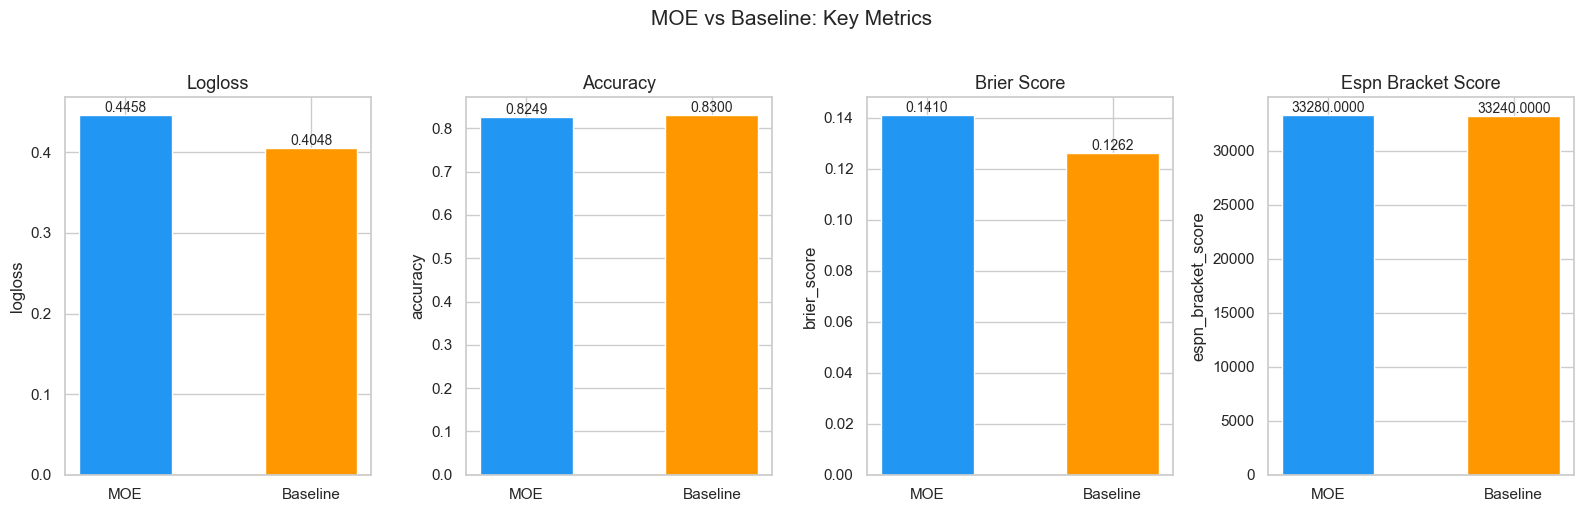

In [5]:
# Pick key metrics to compare in a grouped bar chart
bar_metrics = [k for k in ["logloss", "accuracy", "brier_score", "espn_bracket_score"]
               if k in moe_m and k in bl_m]

fig, axes = plt.subplots(1, len(bar_metrics), figsize=(4 * len(bar_metrics), 5))
if len(bar_metrics) == 1:
    axes = [axes]

for ax, metric in zip(axes, bar_metrics):
    vals = [moe_m[metric], bl_m[metric]]
    colors = ["#2196F3", "#FF9800"]
    bars = ax.bar(["MOE", "Baseline"], vals, color=colors, width=0.5)
    ax.set_title(metric.replace("_", " ").title(), fontsize=13)
    ax.set_ylabel(metric)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"{val:.4f}", ha="center", va="bottom", fontsize=10)

plt.suptitle("MOE vs Baseline: Key Metrics", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 6. Viz: Logloss by Year

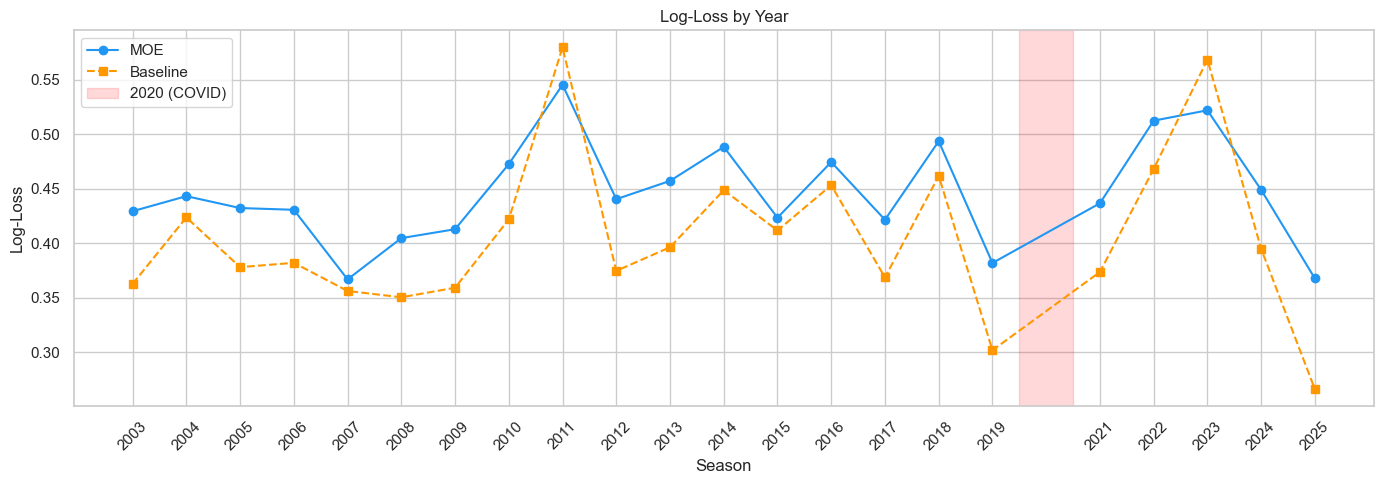

In [6]:
moe_by_year = moe_result.metrics_by_year.copy()
bl_by_year = bl_result.metrics_by_year.copy()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(moe_by_year["season"], moe_by_year["logloss"], "o-", label="MOE", color="#2196F3")
ax.plot(bl_by_year["season"], bl_by_year["logloss"], "s--", label="Baseline", color="#FF9800")

# Annotate COVID gap
if 2020 in set(SKIP_YEARS):
    ax.axvspan(2019.5, 2020.5, alpha=0.15, color="red", label="2020 (COVID)")

ax.set_xlabel("Season")
ax.set_ylabel("Log-Loss")
ax.set_title("Log-Loss by Year")
ax.legend()
ax.set_xticks(moe_by_year["season"].values)
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 7. Viz: Accuracy by Year

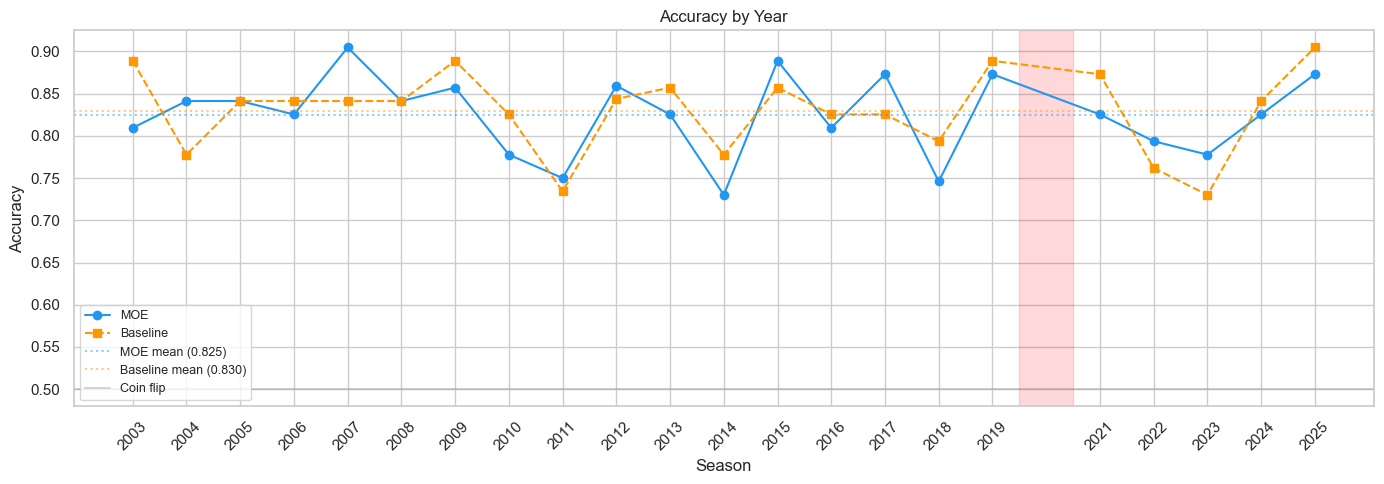

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(moe_by_year["season"], moe_by_year["accuracy"], "o-", label="MOE", color="#2196F3")
ax.plot(bl_by_year["season"], bl_by_year["accuracy"], "s--", label="Baseline", color="#FF9800")

# Reference lines
ax.axhline(moe_m["accuracy"], ls=":", color="#2196F3", alpha=0.5, label=f"MOE mean ({moe_m['accuracy']:.3f})")
ax.axhline(bl_m["accuracy"], ls=":", color="#FF9800", alpha=0.5, label=f"Baseline mean ({bl_m['accuracy']:.3f})")
ax.axhline(0.5, ls="-", color="gray", alpha=0.3, label="Coin flip")

if 2020 in set(SKIP_YEARS):
    ax.axvspan(2019.5, 2020.5, alpha=0.15, color="red")

ax.set_xlabel("Season")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy by Year")
ax.legend(loc="lower left", fontsize=9)
ax.set_xticks(moe_by_year["season"].values)
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 8. Viz: ESPN Bracket Score by Year

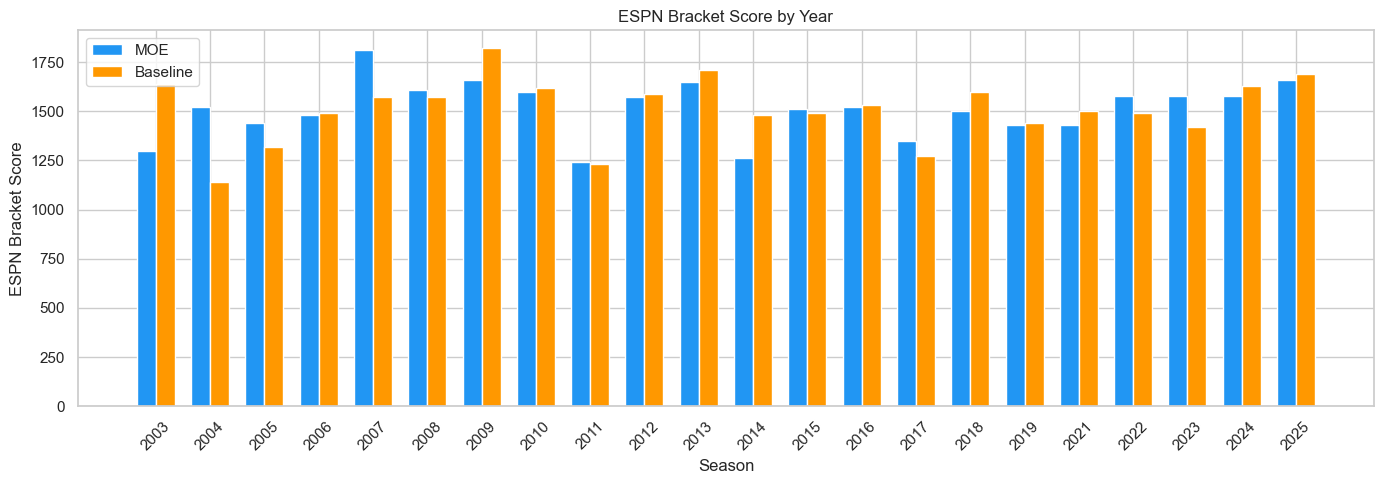

In [8]:
has_espn = "espn_bracket_score" in moe_by_year.columns and "espn_bracket_score" in bl_by_year.columns

if has_espn:
    fig, ax = plt.subplots(figsize=(14, 5))
    x = np.arange(len(moe_by_year))
    w = 0.35
    ax.bar(x - w / 2, moe_by_year["espn_bracket_score"].values, w, label="MOE", color="#2196F3")
    ax.bar(x + w / 2, bl_by_year["espn_bracket_score"].values, w, label="Baseline", color="#FF9800")
    ax.set_xticks(x)
    ax.set_xticklabels(moe_by_year["season"].values, rotation=45)
    ax.set_xlabel("Season")
    ax.set_ylabel("ESPN Bracket Score")
    ax.set_title("ESPN Bracket Score by Year")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("ESPN bracket score not available in metrics_by_year; skipping.")

## 9. Viz: Year-over-Year Dashboard

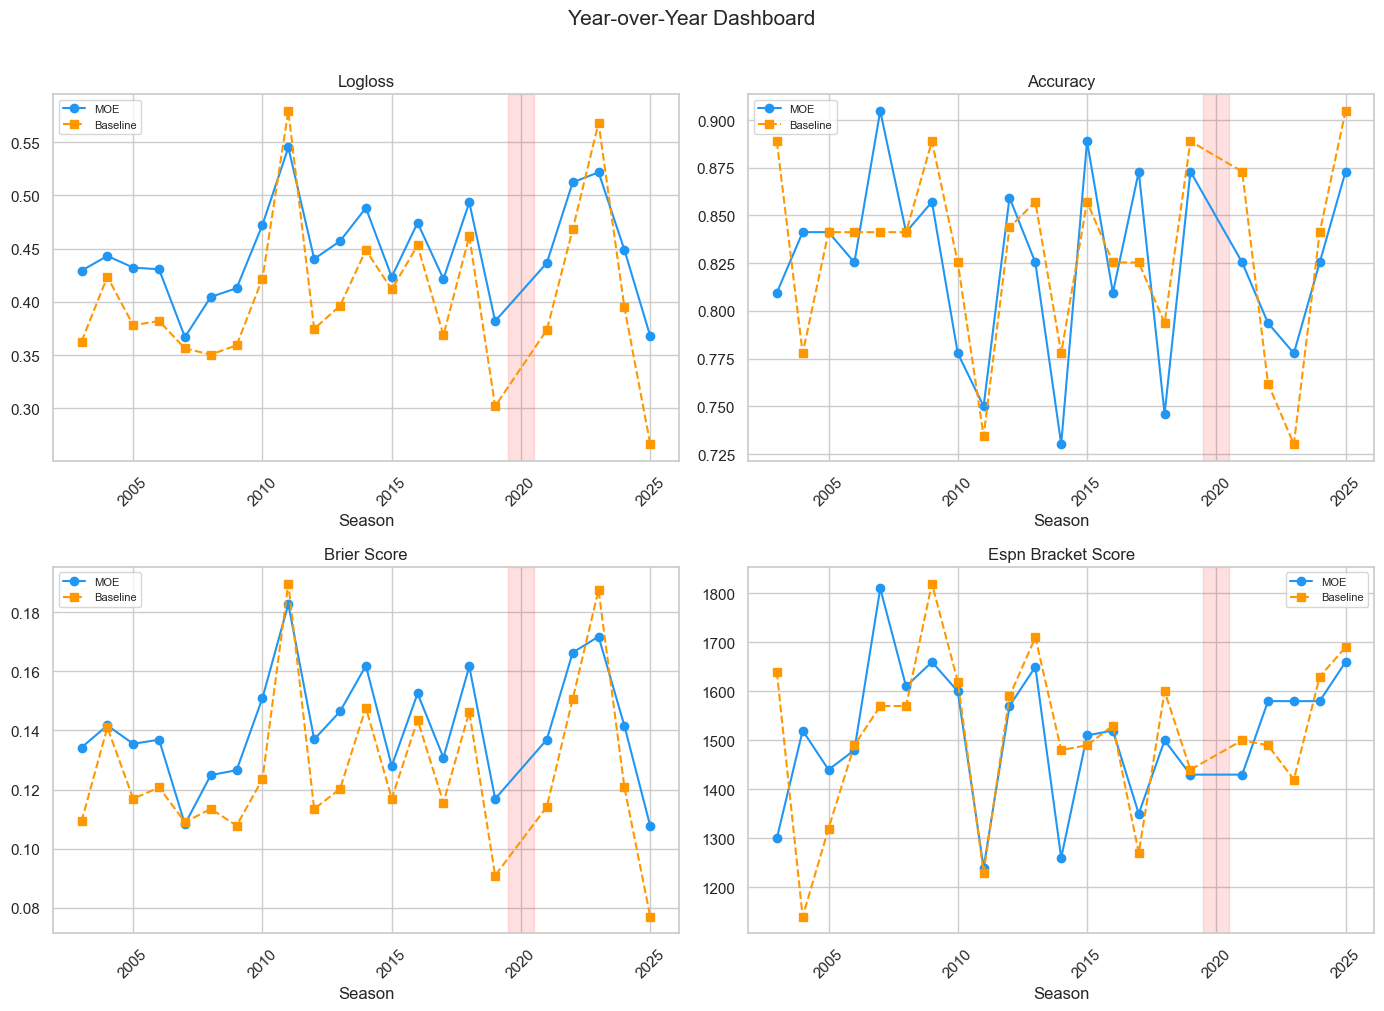

In [9]:
dash_metrics = [m for m in ["logloss", "accuracy", "brier_score", "espn_bracket_score"]
                if m in moe_by_year.columns and m in bl_by_year.columns]

n_panels = min(len(dash_metrics), 4)
if n_panels == 0:
    print("No year-level metrics to plot in dashboard.")
else:
    nrows = (n_panels + 1) // 2
    ncols = 2 if n_panels > 1 else 1
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))
    axes = np.array(axes).flatten()

    for i, metric in enumerate(dash_metrics[:4]):
        ax = axes[i]
        ax.plot(moe_by_year["season"], moe_by_year[metric], "o-", label="MOE", color="#2196F3")
        ax.plot(bl_by_year["season"], bl_by_year[metric], "s--", label="Baseline", color="#FF9800")
        if 2020 in set(SKIP_YEARS):
            ax.axvspan(2019.5, 2020.5, alpha=0.12, color="red")
        ax.set_title(metric.replace("_", " ").title())
        ax.set_xlabel("Season")
        ax.legend(fontsize=8)
        ax.tick_params(axis="x", rotation=45)

    # Hide unused subplots
    for j in range(n_panels, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Year-over-Year Dashboard", fontsize=15, y=1.01)
    plt.tight_layout()
    plt.show()

## 10. Overfitting Analysis

In [10]:
# Estimate per-year "train" logloss from the full pool excluding that year,
# then compare against test logloss for that year.
# Since we only have test predictions per fold, we approximate by looking at
# how each year's test logloss compares to the grand mean across other years.

preds = moe_result.predictions.copy()

# Compute per-year test logloss
yearly_ll = []
for season, grp in preds.groupby("season"):
    ll = compute_logloss(grp["y_true"].values, grp["p_blend"].values)
    # "Train" proxy: average logloss of all OTHER years' test predictions
    other = preds[preds["season"] != season]
    train_proxy_ll = compute_logloss(other["y_true"].values, other["p_blend"].values)
    yearly_ll.append({"season": season, "test_logloss": ll, "train_proxy_logloss": train_proxy_ll})

overfit_df = pd.DataFrame(yearly_ll)
overfit_df["gap"] = overfit_df["test_logloss"] - overfit_df["train_proxy_logloss"]

print("Overfitting Analysis (test - train_proxy logloss):")
print(f"  Mean gap: {overfit_df['gap'].mean():.4f}")
print(f"  Std gap:  {overfit_df['gap'].std():.4f}")
print(f"  Max gap:  {overfit_df['gap'].max():.4f} (season {overfit_df.loc[overfit_df['gap'].idxmax(), 'season']})")
overfit_df.head(10)

Overfitting Analysis (test - train_proxy logloss):
  Mean gap: -0.0001
  Std gap:  0.0495
  Max gap:  0.1042 (season 2011)


,season,test_logloss,train_proxy_logloss,gap
0,2003,0.429372,0.446559,-0.017187
1,2004,0.443151,0.445904,-0.002753
2,2005,0.432272,0.446422,-0.014149
3,2006,0.430663,0.446498,-0.015835
4,2007,0.366922,0.449529,-0.082607
5,2008,0.404702,0.447732,-0.043030
6,2009,0.412868,0.447344,-0.034476
7,2010,0.472485,0.444510,0.027975
8,2011,0.545175,0.440975,0.104200
9,2012,0.440397,0.446039,-0.005643


## 11. Viz: Train vs Test Logloss Gap

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


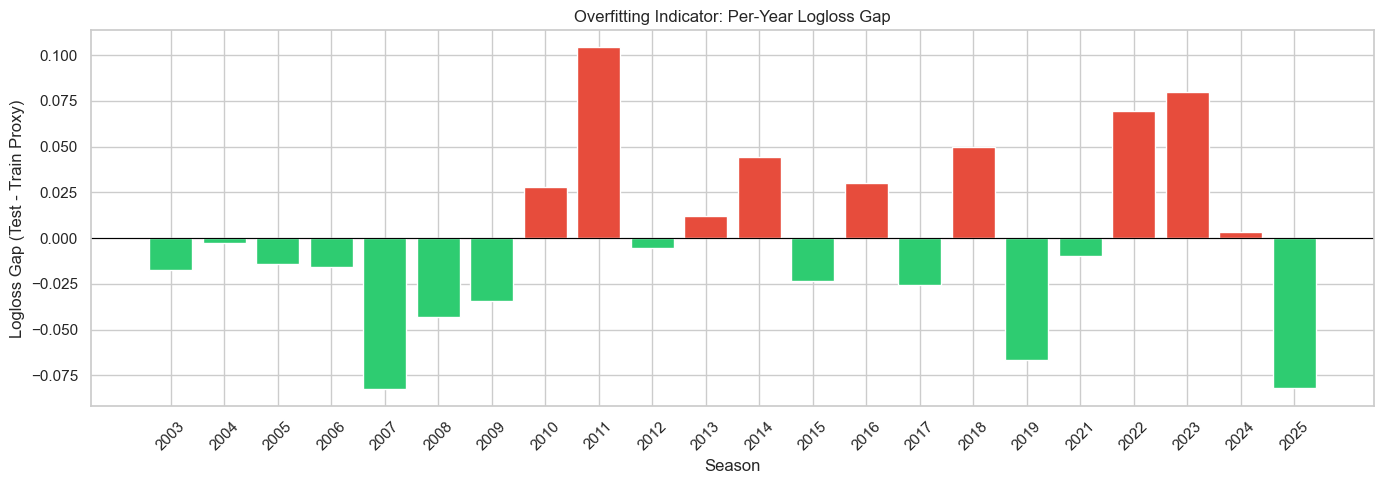

In [11]:
fig, ax = plt.subplots(figsize=(14, 5))
colors = ["#e74c3c" if g > 0 else "#2ecc71" for g in overfit_df["gap"]]
ax.bar(overfit_df["season"].astype(str), overfit_df["gap"], color=colors)
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("Season")
ax.set_ylabel("Logloss Gap (Test - Train Proxy)")
ax.set_title("Overfitting Indicator: Per-Year Logloss Gap")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 12. Viz: Expert Prediction Correlation Matrix

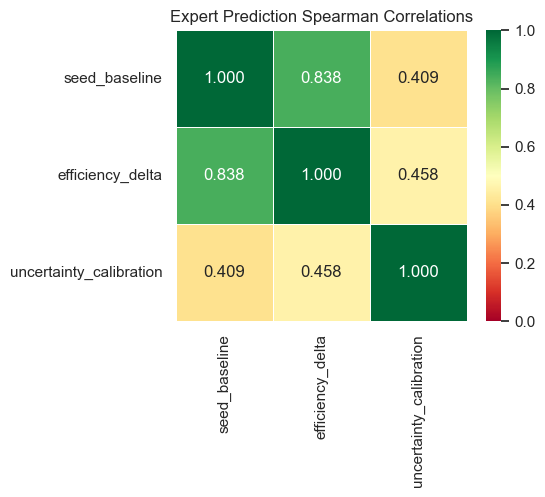

In [12]:
expert_cols = [c for c in ["p_seed", "p_eff", "p_unc"] if c in preds.columns]

if len(expert_cols) >= 2:
    # Use the stored expert_agreement if available, else compute
    agreement = moe_result.expert_agreement
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        agreement, annot=True, fmt=".3f", cmap="RdYlGn",
        vmin=0, vmax=1, square=True, ax=ax, linewidths=0.5,
    )
    ax.set_title("Expert Prediction Spearman Correlations")
    plt.tight_layout()
    plt.show()
else:
    print("Expert prediction columns not found; showing stored expert_agreement.")
    print(moe_result.expert_agreement)

## 13. Viz: Expert Decorrelation by Fold

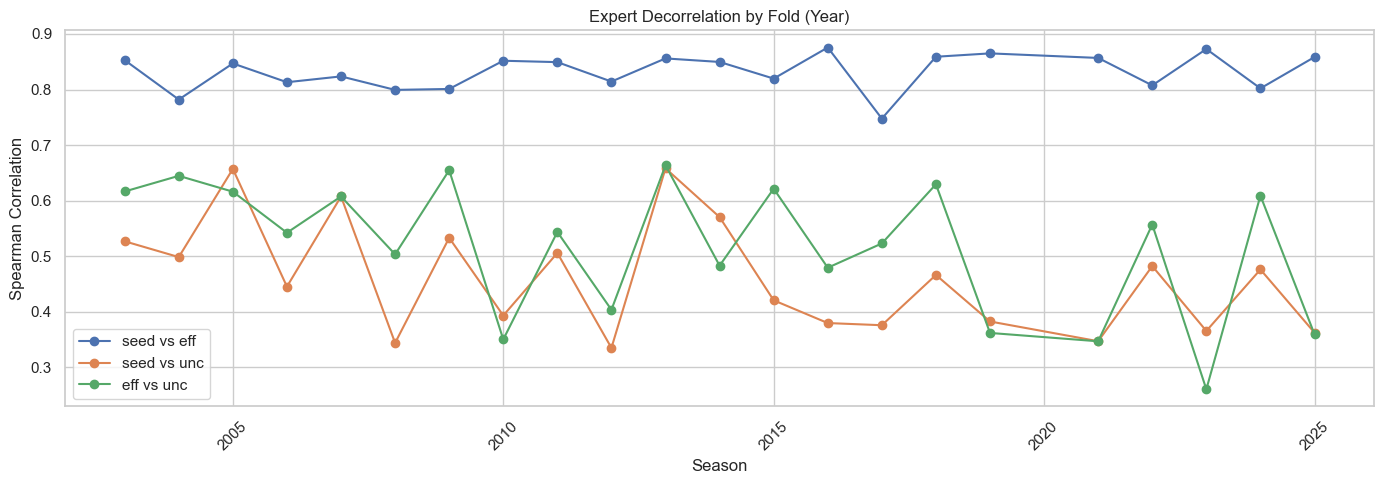

In [13]:
expert_cols = [c for c in ["p_seed", "p_eff", "p_unc"] if c in preds.columns]
expert_labels = ["seed", "eff", "unc"][:len(expert_cols)]

if len(expert_cols) >= 2:
    pairs = []
    for i in range(len(expert_cols)):
        for j in range(i + 1, len(expert_cols)):
            pairs.append((expert_cols[i], expert_cols[j],
                          f"{expert_labels[i]} vs {expert_labels[j]}"))

    decorr_rows = []
    for season, grp in preds.groupby("season"):
        for c1, c2, pair_name in pairs:
            rho, _ = spearmanr(grp[c1].values, grp[c2].values)
            decorr_rows.append({"season": season, "pair": pair_name, "spearman": rho})

    decorr_df = pd.DataFrame(decorr_rows)

    fig, ax = plt.subplots(figsize=(14, 5))
    for pair_name in decorr_df["pair"].unique():
        sub = decorr_df[decorr_df["pair"] == pair_name]
        ax.plot(sub["season"], sub["spearman"], "o-", label=pair_name)

    ax.set_xlabel("Season")
    ax.set_ylabel("Spearman Correlation")
    ax.set_title("Expert Decorrelation by Fold (Year)")
    ax.legend()
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Insufficient expert columns for decorrelation analysis.")

## 14. Viz: Blended vs Individual Expert Logloss per Fold

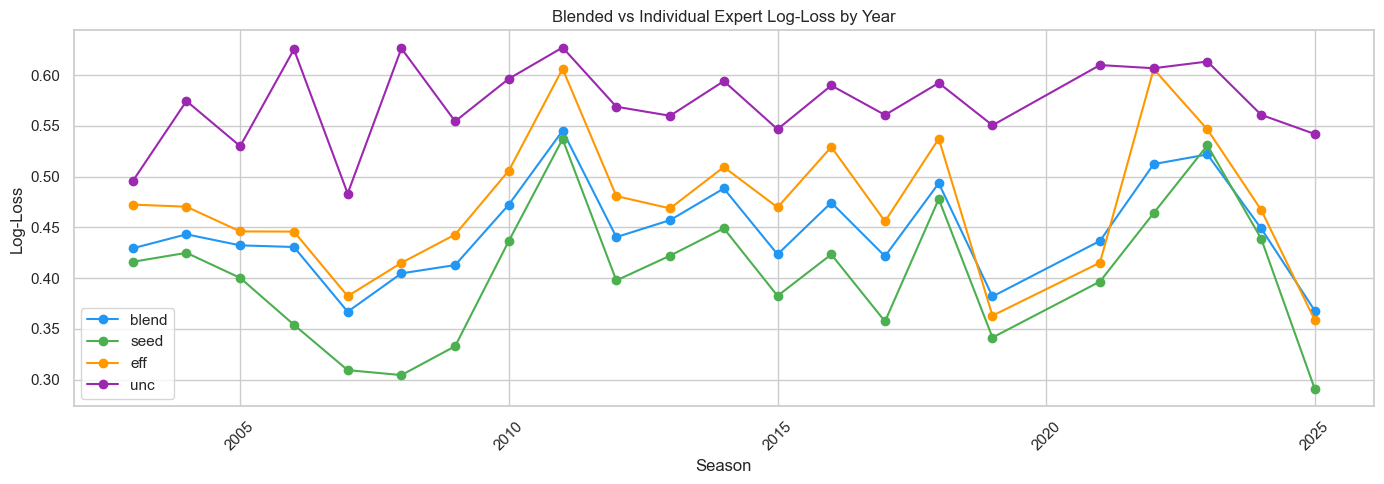

In [14]:
expert_cols = [c for c in ["p_seed", "p_eff", "p_unc"] if c in preds.columns]
all_pred_cols = ["p_blend"] + expert_cols
col_labels = ["blend"] + [c.replace("p_", "") for c in expert_cols]

if len(all_pred_cols) >= 2:
    ll_rows = []
    for season, grp in preds.groupby("season"):
        row = {"season": season}
        for col, label in zip(all_pred_cols, col_labels):
            row[label] = compute_logloss(grp["y_true"].values, grp[col].values)
        ll_rows.append(row)

    expert_ll_df = pd.DataFrame(ll_rows)

    fig, ax = plt.subplots(figsize=(14, 5))
    colors_map = {"blend": "#2196F3", "seed": "#4CAF50", "eff": "#FF9800", "unc": "#9C27B0"}
    for label in col_labels:
        ax.plot(expert_ll_df["season"], expert_ll_df[label], "o-",
                label=label, color=colors_map.get(label, None))

    ax.set_xlabel("Season")
    ax.set_ylabel("Log-Loss")
    ax.set_title("Blended vs Individual Expert Log-Loss by Year")
    ax.legend()
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Only blend predictions available; individual expert logloss comparison skipped.")

## 15. Viz: Weight Distribution (All Games)

/var/folders/wq/qc40qkf92p54dgw397rwdwch0000gn/T/ipykernel_87677/2106136431.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=weight_data, x="Expert", y="Weight", palette=weight_colors, ax=ax)


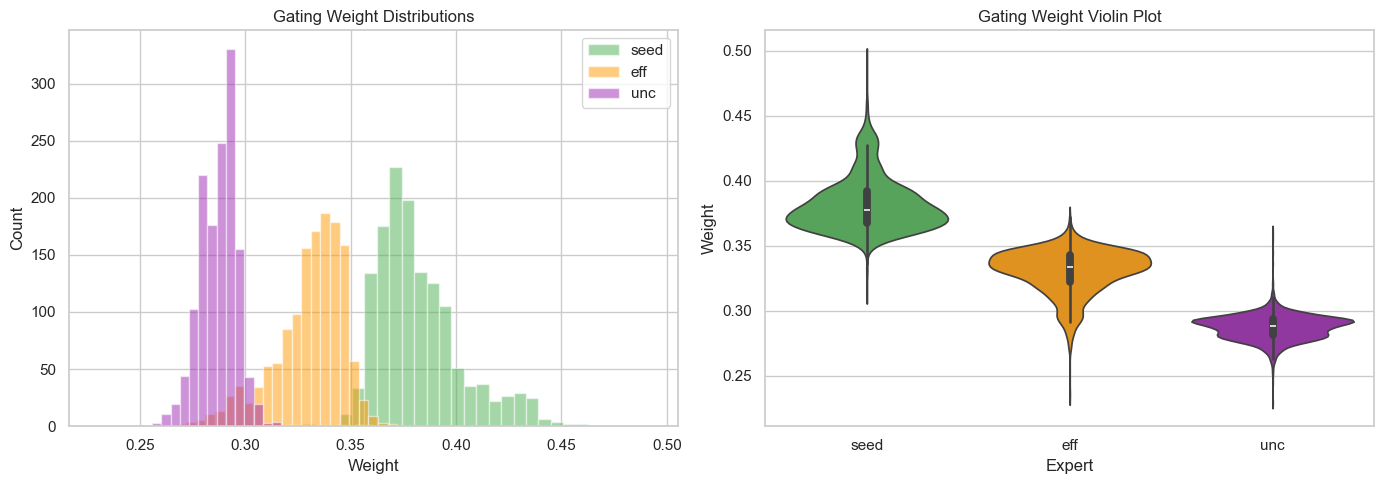

Weight summary statistics:
          w_seed      w_eff      w_unc
count  1388.0000  1388.0000  1388.0000
mean      0.3821     0.3305     0.2875
std       0.0206     0.0167     0.0097
min       0.3153     0.2356     0.2297
25%       0.3679     0.3222     0.2811
50%       0.3772     0.3338     0.2886
75%       0.3918     0.3429     0.2935
max       0.4921     0.3721     0.3608


In [15]:
weight_cols = [c for c in ["w_seed", "w_eff", "w_unc"] if c in preds.columns]

if len(weight_cols) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Stacked histogram
    ax = axes[0]
    weight_labels = [c.replace("w_", "") for c in weight_cols]
    weight_colors = ["#4CAF50", "#FF9800", "#9C27B0"][:len(weight_cols)]
    for col, label, color in zip(weight_cols, weight_labels, weight_colors):
        ax.hist(preds[col], bins=30, alpha=0.5, label=label, color=color)
    ax.set_xlabel("Weight")
    ax.set_ylabel("Count")
    ax.set_title("Gating Weight Distributions")
    ax.legend()

    # Violin plot
    ax = axes[1]
    weight_data = preds[weight_cols].melt(var_name="Expert", value_name="Weight")
    weight_data["Expert"] = weight_data["Expert"].str.replace("w_", "")
    sns.violinplot(data=weight_data, x="Expert", y="Weight", palette=weight_colors, ax=ax)
    ax.set_title("Gating Weight Violin Plot")

    plt.tight_layout()
    plt.show()

    # Summary stats
    print("Weight summary statistics:")
    print(preds[weight_cols].describe().round(4))
else:
    print("Weight columns not found in predictions; skipping weight distribution.")

## 16. Viz: Mean Weight by Round

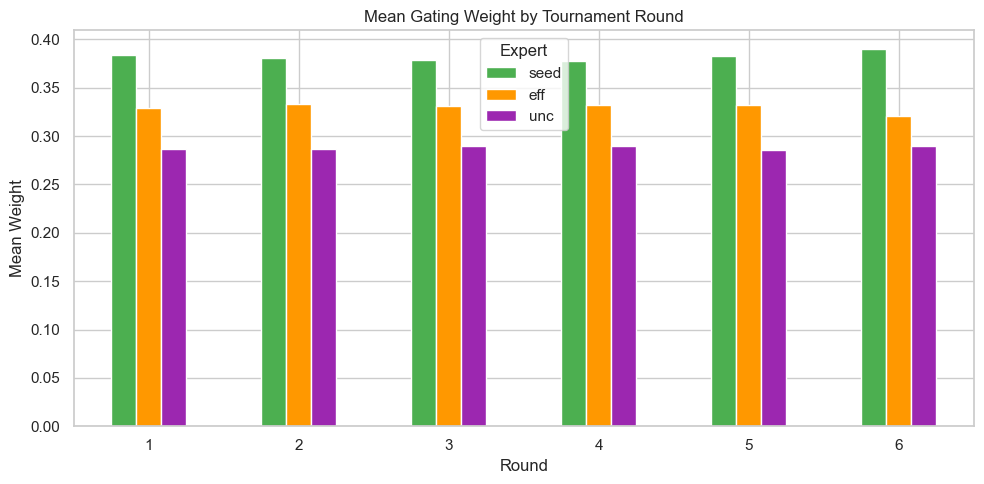

In [16]:
weight_cols = [c for c in ["w_seed", "w_eff", "w_unc"] if c in preds.columns]
has_rounds = "round" in preds.columns and preds["round"].notna().any()

if len(weight_cols) >= 2 and has_rounds:
    round_weights = preds.groupby("round")[weight_cols].mean()
    round_weights.columns = [c.replace("w_", "") for c in weight_cols]

    fig, ax = plt.subplots(figsize=(10, 5))
    round_weights.plot(kind="bar", ax=ax, color=["#4CAF50", "#FF9800", "#9C27B0"][:len(weight_cols)])
    ax.set_xlabel("Round")
    ax.set_ylabel("Mean Weight")
    ax.set_title("Mean Gating Weight by Tournament Round")
    ax.legend(title="Expert")
    ax.tick_params(axis="x", rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Weight columns or round info not available; skipping.")

## 17. Viz: Weight Shift Over Eras

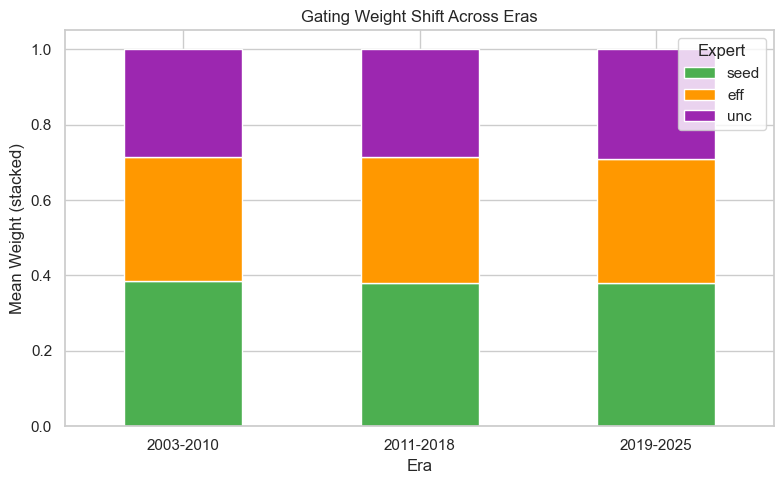

In [17]:
weight_cols = [c for c in ["w_seed", "w_eff", "w_unc"] if c in preds.columns]

if len(weight_cols) >= 2 and "season" in preds.columns:
    # Define eras
    def assign_era(year):
        if year <= 2010:
            return "2003-2010"
        elif year <= 2018:
            return "2011-2018"
        else:
            return "2019-2025"

    preds["era"] = preds["season"].apply(assign_era)
    era_weights = preds.groupby("era")[weight_cols].mean()
    era_weights.columns = [c.replace("w_", "") for c in weight_cols]

    fig, ax = plt.subplots(figsize=(8, 5))
    era_weights.plot(
        kind="bar", stacked=True, ax=ax,
        color=["#4CAF50", "#FF9800", "#9C27B0"][:len(weight_cols)],
    )
    ax.set_xlabel("Era")
    ax.set_ylabel("Mean Weight (stacked)")
    ax.set_title("Gating Weight Shift Across Eras")
    ax.legend(title="Expert")
    ax.tick_params(axis="x", rotation=0)
    plt.tight_layout()
    plt.show()

    # Cleanup temp column
    preds.drop(columns=["era"], inplace=True)
else:
    print("Weight columns or season info not available; skipping.")

## 18. Viz: Calibration Reliability Diagrams

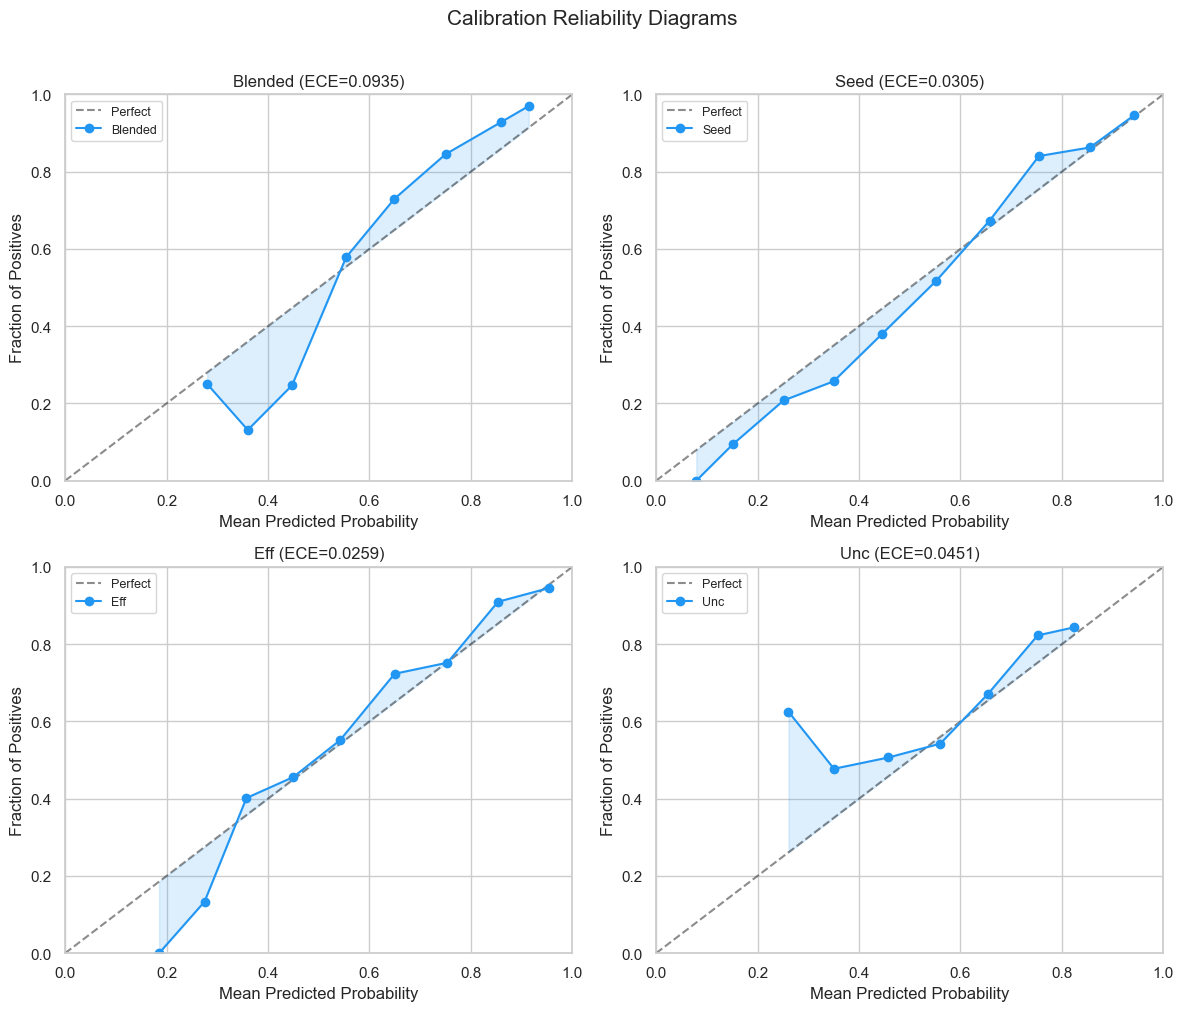

In [18]:
y_true = preds["y_true"].values
expert_cols = [c for c in ["p_seed", "p_eff", "p_unc"] if c in preds.columns]
all_pred_cols = ["p_blend"] + expert_cols
all_labels = ["Blended"] + [c.replace("p_", "").title() for c in expert_cols]

n_plots = len(all_pred_cols)
nrows = (n_plots + 1) // 2
ncols = 2 if n_plots > 1 else 1

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = np.array(axes).flatten()

for i, (col, label) in enumerate(zip(all_pred_cols, all_labels)):
    ax = axes[i]
    y_pred_col = preds[col].values

    try:
        frac_pos, mean_pred = compute_calibration_curve(y_true, y_pred_col)
        ece = compute_calibration_error(y_true, y_pred_col)

        ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Perfect")
        ax.plot(mean_pred, frac_pos, "o-", color="#2196F3", label=f"{label}")
        ax.fill_between(mean_pred, frac_pos, mean_pred, alpha=0.15, color="#2196F3")
        ax.set_xlabel("Mean Predicted Probability")
        ax.set_ylabel("Fraction of Positives")
        ax.set_title(f"{label} (ECE={ece:.4f})")
        ax.legend(fontsize=9)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
    except Exception as e:
        ax.text(0.5, 0.5, f"Error: {e}", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"{label} (error)")

# Hide unused
for j in range(n_plots, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Calibration Reliability Diagrams", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## 19. Viz: Per-Expert ECE Comparison

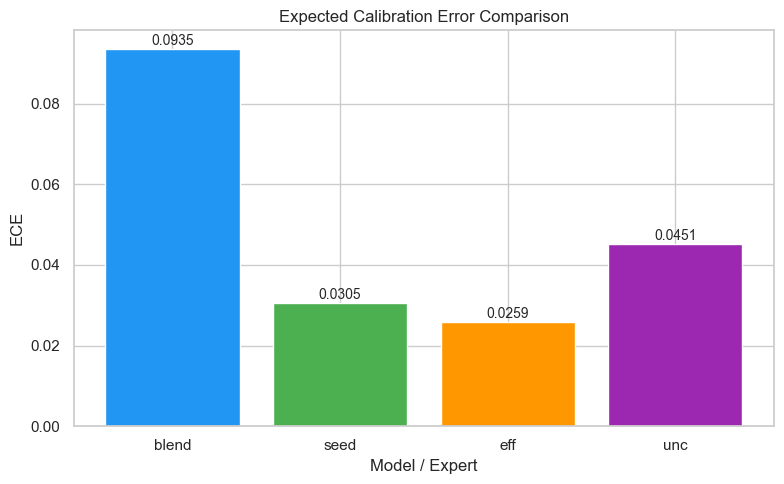

In [19]:
expert_cols = [c for c in ["p_seed", "p_eff", "p_unc"] if c in preds.columns]

ece_data = []
# Blend ECE
ece_data.append({"model": "blend", "ece": compute_calibration_error(y_true, preds["p_blend"].values)})

# Expert ECEs
for col in expert_cols:
    label = col.replace("p_", "")
    ece_data.append({"model": label, "ece": compute_calibration_error(y_true, preds[col].values)})

ece_df = pd.DataFrame(ece_data)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0"][:len(ece_df)]
ax.bar(ece_df["model"], ece_df["ece"], color=colors)
for i, row in ece_df.iterrows():
    ax.text(i, row["ece"] + 0.001, f"{row['ece']:.4f}", ha="center", fontsize=10)
ax.set_xlabel("Model / Expert")
ax.set_ylabel("ECE")
ax.set_title("Expected Calibration Error Comparison")
plt.tight_layout()
plt.show()

## 20. Viz: Per-Round Comparison

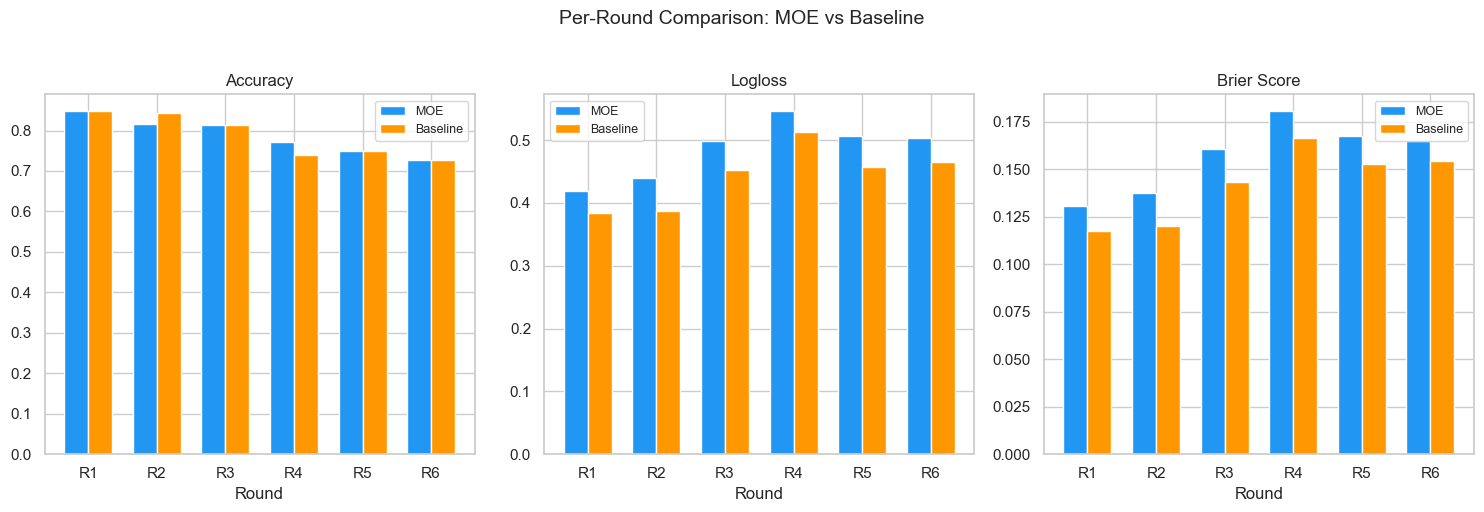

In [20]:
moe_preds = moe_result.predictions
bl_preds = bl_result.predictions

has_rounds_moe = "round" in moe_preds.columns and moe_preds["round"].notna().any()
has_rounds_bl = "round" in bl_preds.columns and bl_preds["round"].notna().any()

if has_rounds_moe and has_rounds_bl:
    moe_rd = compute_round_breakdown(
        moe_preds["y_true"].values, moe_preds["p_blend"].values, moe_preds["round"].values
    )
    bl_rd = compute_round_breakdown(
        bl_preds["y_true"].values, bl_preds["p_blend"].values, bl_preds["round"].values
    )

    round_metrics = ["accuracy", "logloss", "brier_score"]
    n_rm = len(round_metrics)
    fig, axes = plt.subplots(1, n_rm, figsize=(5 * n_rm, 5))
    if n_rm == 1:
        axes = [axes]

    for ax, metric in zip(axes, round_metrics):
        # Merge on round
        merged_rd = moe_rd[["round", metric]].merge(
            bl_rd[["round", metric]], on="round", suffixes=("_moe", "_bl")
        )
        x = np.arange(len(merged_rd))
        w = 0.35
        ax.bar(x - w / 2, merged_rd[f"{metric}_moe"], w, label="MOE", color="#2196F3")
        ax.bar(x + w / 2, merged_rd[f"{metric}_bl"], w, label="Baseline", color="#FF9800")
        ax.set_xticks(x)
        ax.set_xticklabels([f"R{int(r)}" for r in merged_rd["round"]])
        ax.set_title(metric.replace("_", " ").title())
        ax.set_xlabel("Round")
        ax.legend(fontsize=9)

    plt.suptitle("Per-Round Comparison: MOE vs Baseline", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Round information not available; skipping per-round comparison.")

## 21. Viz: Upset Detection Rate

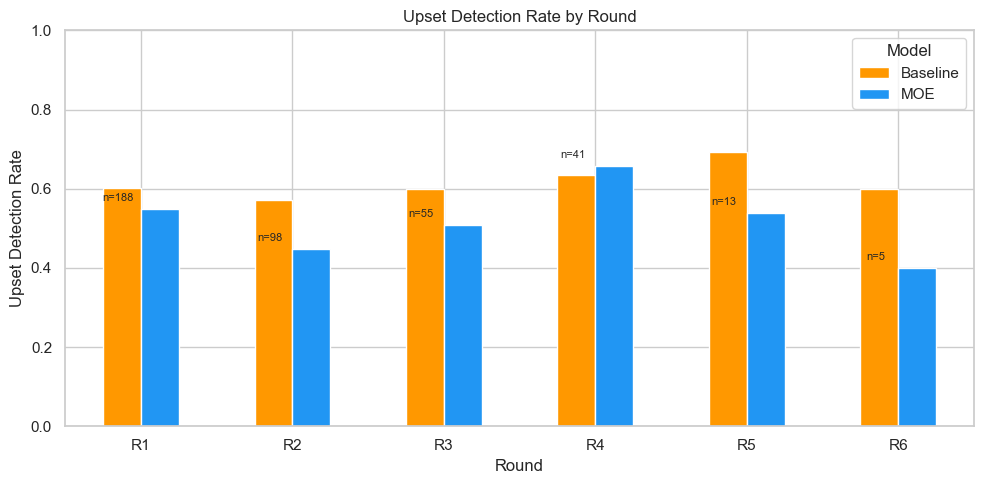


Upset Detection Summary:
 round    model  n_upsets  detected  detection_rate
     1      MOE       188       103        0.547872
     2      MOE        98        44        0.448980
     3      MOE        55        28        0.509091
     4      MOE        41        27        0.658537
     5      MOE        13         7        0.538462
     6      MOE         5         2        0.400000
     1 Baseline       188       113        0.601064
     2 Baseline        98        56        0.571429
     3 Baseline        55        33        0.600000
     4 Baseline        41        26        0.634146
     5 Baseline        13         9        0.692308
     6 Baseline         5         3        0.600000


In [21]:
has_rounds = "round" in moe_preds.columns and moe_preds["round"].notna().any()

if has_rounds:
    # An "upset" is y_true == 0 (lower-seeded team won).
    # Correctly predicted upset: model gives p_blend < 0.5 when y_true == 0.

    upset_rows = []
    for df, model_name in [(moe_preds, "MOE"), (bl_preds, "Baseline")]:
        for r in sorted(df["round"].dropna().unique()):
            mask_round = df["round"] == r
            upsets = df[mask_round & (df["y_true"] == 0)]
            if len(upsets) == 0:
                continue
            detected = (upsets["p_blend"] < 0.5).sum()
            rate = detected / len(upsets)
            upset_rows.append({
                "round": int(r), "model": model_name,
                "n_upsets": len(upsets), "detected": int(detected),
                "detection_rate": rate,
            })

    upset_df = pd.DataFrame(upset_rows)

    if len(upset_df) > 0:
        fig, ax = plt.subplots(figsize=(10, 5))
        pivot = upset_df.pivot(index="round", columns="model", values="detection_rate")
        pivot.plot(kind="bar", ax=ax, color={"MOE": "#2196F3", "Baseline": "#FF9800"})
        ax.set_xlabel("Round")
        ax.set_ylabel("Upset Detection Rate")
        ax.set_title("Upset Detection Rate by Round")
        ax.set_xticklabels([f"R{int(r)}" for r in pivot.index], rotation=0)
        ax.legend(title="Model")
        ax.set_ylim(0, 1)

        # Annotate with count of upsets
        moe_upsets = upset_df[upset_df["model"] == "MOE"]
        for _, row in moe_upsets.iterrows():
            ax.text(
                row["round"] - sorted(pivot.index)[0] - 0.15, row["detection_rate"] + 0.02,
                f"n={row['n_upsets']}", fontsize=8, ha="center",
            )

        plt.tight_layout()
        plt.show()

        # Summary table
        print("\nUpset Detection Summary:")
        print(upset_df.to_string(index=False))
    else:
        print("No upsets found in predictions.")
else:
    print("Round information not available; skipping upset detection analysis.")

## 22. Summary

In [22]:
# Final comparison table
print("=" * 60)
print("FINAL BACKTESTING COMPARISON")
print("=" * 60)

summary_metrics = sorted(set(moe_result.metrics_overall.keys()) & set(bl_result.metrics_overall.keys()))
summary_rows = []
for k in summary_metrics:
    mv = moe_result.metrics_overall[k]
    bv = bl_result.metrics_overall[k]
    delta = mv - bv
    # Determine if MOE is better
    if k in {"logloss", "brier_score"}:
        better = "MOE" if delta < 0 else "Baseline" if delta > 0 else "Tie"
    else:
        better = "MOE" if delta > 0 else "Baseline" if delta < 0 else "Tie"
    summary_rows.append({"Metric": k, "MOE": mv, "Baseline": bv, "Delta": delta, "Winner": better})

summary_df = pd.DataFrame(summary_rows).set_index("Metric")
print(summary_df.to_string(float_format="{:.4f}".format))

# Win counts
moe_wins = (summary_df["Winner"] == "MOE").sum()
bl_wins = (summary_df["Winner"] == "Baseline").sum()
ties = (summary_df["Winner"] == "Tie").sum()
print(f"\nMOE wins: {moe_wins}, Baseline wins: {bl_wins}, Ties: {ties}")

# Key findings
print("\n" + "=" * 60)
print("KEY FINDINGS")
print("=" * 60)

# Logloss comparison
ll_delta = moe_result.metrics_overall.get("logloss", 0) - bl_result.metrics_overall.get("logloss", 0)
if ll_delta < 0:
    print(f"  [+] MOE improves logloss by {abs(ll_delta):.4f} over baseline.")
elif ll_delta > 0:
    print(f"  [-] MOE logloss is {abs(ll_delta):.4f} worse than baseline.")
else:
    print(f"  [=] Logloss is identical between MOE and baseline.")

# Accuracy comparison
acc_delta = moe_result.metrics_overall.get("accuracy", 0) - bl_result.metrics_overall.get("accuracy", 0)
if acc_delta > 0:
    print(f"  [+] MOE improves accuracy by {abs(acc_delta):.4f} over baseline.")
elif acc_delta < 0:
    print(f"  [-] MOE accuracy is {abs(acc_delta):.4f} worse than baseline.")
else:
    print(f"  [=] Accuracy is identical between MOE and baseline.")

# Calibration
moe_ece = moe_result.calibration.get("blend_ece", None)
bl_ece = bl_result.calibration.get("blend_ece", None)
if moe_ece is not None and bl_ece is not None:
    ece_delta = moe_ece - bl_ece
    if ece_delta < 0:
        print(f"  [+] MOE is better calibrated (ECE: {moe_ece:.4f} vs {bl_ece:.4f}).")
    else:
        print(f"  [-] Baseline is better calibrated (ECE: {bl_ece:.4f} vs {moe_ece:.4f}).")

# Expert diversity
agreement = moe_result.expert_agreement
offdiag = agreement.values[np.triu_indices_from(agreement.values, k=1)]
mean_corr = offdiag.mean()
print(f"  [i] Mean expert pairwise Spearman correlation: {mean_corr:.3f}")
if mean_corr < 0.8:
    print(f"      Experts show meaningful diversity (correlation < 0.8).")
else:
    print(f"      Experts are highly correlated; diversity may be insufficient.")

# Year consistency
moe_year_ll = moe_result.metrics_by_year["logloss"]
print(f"  [i] MOE per-year logloss: mean={moe_year_ll.mean():.4f}, std={moe_year_ll.std():.4f}")
print(f"      Range: [{moe_year_ll.min():.4f}, {moe_year_ll.max():.4f}]")

print("\n" + "=" * 60)

FINAL BACKTESTING COMPARISON
                          MOE   Baseline   Delta    Winner
Metric                                                    
accuracy               0.8249     0.8300 -0.0050  Baseline
brier_score            0.1410     0.1262  0.0148  Baseline
espn_bracket_score 33280.0000 33240.0000 40.0000       MOE
logloss                0.4458     0.4048  0.0410  Baseline

MOE wins: 1, Baseline wins: 3, Ties: 0

KEY FINDINGS
  [-] MOE logloss is 0.0410 worse than baseline.
  [-] MOE accuracy is 0.0050 worse than baseline.
  [-] Baseline is better calibrated (ECE: 0.0307 vs 0.0935).
  [i] Mean expert pairwise Spearman correlation: 0.569
      Experts show meaningful diversity (correlation < 0.8).
  [i] MOE per-year logloss: mean=0.4457, std=0.0472
      Range: [0.3669, 0.5452]

